# Survival Analysis: An End-to-End Guide & Case Study
**A Practical Walkthrough Using `scikit-survival` and the Veterans' Administration Lung Cancer Study**

---

### What is Survival Analysis?
**Survival Analysis** (also known as *time-to-event analysis*, *reliability engineering*, or *duration modeling*) is a branch of statistics and machine learning designed to model the time until an event of interest occurs—such as biological death, mechanical breakdown, disease relapse, or customer churn.

### Why Standard Regression Fails for Time-to-Event Data
In standard regression (e.g., Ordinary Least Squares or Logistic Regression), every observation is assumed to have an observed final label. However, real-world time-to-event datasets almost universally contain **Right-Censored** observations:
1. **Right Censoring**: By the end of the study observation window, some patients have *not* experienced the event (e.g., they survived the full study duration or moved away).
2. **Biased Alternatives**:
   - *Dropping censored subjects* discards critical survival data and causes severe survival bias (over-weighting rapid events).
   - *Treating censored times as event times* artificially underestimates true survival duration.

Survival analysis techniques explicitly account for censoring, providing unbiased estimates of risk and time-to-event trajectories.

---

### Core Mathematical Concepts
1. **Survival Function $S(t)$**: The probability that an individual survives past time $t$:
   $$S(t) = P(T > t)$$
2. **Hazard Function $h(t)$**: The instantaneous event rate at time $t$, conditional on survival up to time $t$:
   $$h(t) = \lim_{\Delta t 	o 0} rac{P(t \le T < t + \Delta t \mid T \ge t)}{\Delta t}$$
3. **Censoring Indicator $\delta$**: A binary status where $\delta = 1$ indicates the event was observed, and $\delta = 0$ indicates the observation was censored.

---

### Table of Contents
1. [Setup & Environment](#1.-Setup--Environment)
2. [Dataset Overview & Exploratory Data Analysis (EDA)](#2.-Dataset-Overview--Exploratory-Data-Analysis)
   - 2.1 [Inspecting the Structured Survival Target](#21-Inspecting-the-Structured-Survival-Target-data_y)
   - 2.2 [Inspecting the Clinical Covariates](#22-Inspecting-the-Covariates-data_x)
3. [Non-Parametric Survival Analysis: Kaplan-Meier Estimator](#3.-Non-Parametric-Survival-Analysis-Kaplan-Meier-Estimator)
   - 3.1 [Overall Population Survival Curve](#31-Overall-Population-Survival-Curve)
   - 3.2 [Stratified Survival: Standard vs. Test Treatment](#32-Stratified-Survival-by-Treatment-Arm)
   - 3.3 [Stratified Survival: Histological Cell Types](#33-Stratified-Survival-by-Tumor-Cell-Type)
4. [Semi-Parametric Modeling: Cox Proportional Hazards (Cox PH)](#4.-Semi-Parametric-Modeling-Cox-Proportional-Hazards)
   - 4.1 [Categorical Encoding for Survival Data](#41-Data-Preprocessing-One-Hot-Encoding)
   - 4.2 [Model Training](#42-Fitting-the-Cox-Proportional-Hazards-Model)
   - 4.3 [Interpreting Coefficients & Hazard Ratios](#43-Interpreting-Model-Coefficients--Hazard-Ratios)
5. [Predicting Individualized Patient Survival Curves](#5.-Predicting-Individualized-Patient-Survival-Curves)
6. [Model Evaluation: Harrell's Concordance Index (C-Index)](#6.-Model-Evaluation-Harrells-Concordance-Index)
7. [Advanced Feature Selection & Cross-Validated Pipeline Tuning](#7.-Advanced-Feature-Selection--Cross-Validated-Pipeline-Tuning)
   - 7.1 [Univariate Feature Importance Scoring](#71-Univariate-Feature-Evaluation)
   - 7.2 [Building an End-to-End Scikit-Learn Pipeline](#72-Building-an-Integrated-Pipeline)
   - 7.3 [Cross-Validation Grid Search for Optimal Feature Count](#73-Cross-Validation--Hyperparameter-Tuning)
   - 7.4 [Final Tuned Model & Significant Biomarkers](#74-Final-Tuned-Model-Evaluation)
8. [Summary & Key Takeaways](#8.-Summary--Key-Takeaways)


## 1. Setup & Environment
In this section, we verify dependencies and import essential libraries:
- **`sksurv` (`scikit-survival`)**: Dedicated survival analysis toolkit built on top of Scikit-Learn.
- **`sklearn`**: Pipeline construction, cross-validation, and feature selection tools.
- **`pandas` & `numpy`**: Data manipulation and structured array processing.
- **`matplotlib`**: Publication-quality survival curve visualization.


In [1]:
# Optional: Uncomment and run if scikit-survival is not yet installed in your environment
# !pip install scikit-survival

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Scikit-Survival modules
from sksurv.datasets import load_veterans_lung_cancer
from sksurv.nonparametric import kaplan_meier_estimator
from sksurv.preprocessing import OneHotEncoder
from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.metrics import concordance_index_censored

# Scikit-Learn modules
from sklearn import set_config
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest
from sklearn.model_selection import GridSearchCV, KFold

# Visualization and pandas display settings
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11
pd.set_option('display.max_columns', 300)
set_config(display="text")

print("All dependencies successfully imported!")


All dependencies successfully imported!


## 2. Dataset Overview & Exploratory Data Analysis
We use the benchmark **Veterans' Administration (VA) Lung Cancer Study** dataset (`load_veterans_lung_cancer()`).
This randomized clinical trial evaluated the effect of a test chemotherapy regimen compared to standard therapy on male patients with advanced, inoperable lung cancer.

### Clinical Covariates (`data_x`):
- `Treatment`: Type of chemotherapy regimen (`standard` vs. `test`).
- `Celltype`: Histological subtype of tumor (`squamous`, `smallcell`, `adeno`, `large`).
- `Karnofsky_score`: Karnofsky performance status (scale 10–100, where 100 indicates normal physical activity without disease symptoms, and lower scores indicate increasing disability).
- `Months_from_Diagnosis`: Duration in months from initial cancer diagnosis to study enrollment.
- `Age_in_years`: Age of the patient at enrollment.
- `Prior_therapy`: Prior chemotherapy received (`yes` or `no`).

### Survival Target (`data_y`):
In survival analysis, target variables are structured arrays containing two values per observation:
1. `Status`: Boolean indicator (`True` = death event occurred, `False` = right-censored).
2. `Survival_in_days`: Number of days from study entry to event or last contact.


In [2]:
# Load the dataset
data_x, data_y = load_veterans_lung_cancer()

print(f"Features shape (X): {data_x.shape}")
print(f"Target shape   (y): {data_y.shape}")


Features shape (X): (137, 6)
Target shape   (y): (137,)


### 2.1 Inspecting the Structured Survival Target (`data_y`)
Let's convert `data_y` into a pandas DataFrame to inspect the distribution of events versus right-censored patients.


In [3]:
df_y = pd.DataFrame(data_y)

total_patients = len(df_y)
events_observed = df_y["Status"].sum()
censored_count = total_patients - events_observed

print(f"Total Patients:        {total_patients}")
print(f"Observed Deaths:       {events_observed} ({events_observed / total_patients:.1%})")
print(f"Right-Censored:        {censored_count} ({censored_count / total_patients:.1%})")
print(f"Median Survival Time:  {df_y['Survival_in_days'].median():.0f} days")
print(f"Min / Max Days:        {df_y['Survival_in_days'].min()} / {df_y['Survival_in_days'].max()} days")

df_y.head(10)


Total Patients:        137
Observed Deaths:       128 (93.4%)
Right-Censored:        9 (6.6%)
Median Survival Time:  80 days
Min / Max Days:        1.0 / 999.0 days


,Status,Survival_in_days
0,True,72.0
1,True,411.0
2,True,228.0
3,True,126.0
4,True,118.0
5,True,10.0
6,True,82.0
7,True,110.0
8,True,314.0
9,False,100.0


### 2.2 Inspecting the Covariates (`data_x`)
Let's inspect the first few rows, column data types, and descriptive statistics of the patient features.


In [4]:
# Display first 5 records of patient covariates
data_x.head()


,Age_in_years,Celltype,Karnofsky_score,Months_from_Diagnosis,Prior_therapy,Treatment
0,69.0,squamous,60.0,7.0,no,standard
1,64.0,squamous,70.0,5.0,yes,standard
2,38.0,squamous,60.0,3.0,no,standard
3,63.0,squamous,60.0,9.0,yes,standard
4,65.0,squamous,70.0,11.0,yes,standard


In [5]:
# Descriptive statistics for numerical features
data_x.describe()


,Age_in_years,Karnofsky_score,Months_from_Diagnosis
count,137.000000,137.000000,137.000000
mean,58.306569,58.569343,8.773723
std,10.541628,20.039592,10.612141
min,34.000000,10.000000,1.000000
25%,51.000000,40.000000,3.000000
50%,62.000000,60.000000,5.000000
75%,66.000000,75.000000,11.000000
max,81.000000,99.000000,87.000000


In [6]:
# Categorical feature distributions
print("--- Treatment Arm Distribution ---")
print(data_x["Treatment"].value_counts())
print("\n--- Histological Cell Type Distribution ---")
print(data_x["Celltype"].value_counts())
print("\n--- Prior Therapy Distribution ---")
print(data_x["Prior_therapy"].value_counts())


--- Treatment Arm Distribution ---
standard    69
test        68
Name: Treatment, dtype: int64

--- Histological Cell Type Distribution ---
smallcell    48
squamous     35
adeno        27
large        27
Name: Celltype, dtype: int64

--- Prior Therapy Distribution ---
no     97
yes    40
Name: Prior_therapy, dtype: int64


## 3. Non-Parametric Survival Analysis: Kaplan-Meier Estimator

The **Kaplan-Meier (KM) Estimator** is the standard non-parametric method for estimating the survival function $S(t) = P(T > t)$.

It computes the probability of surviving past consecutive distinct event times $t_i$:
$$\hat{S}(t) = \prod_{t_i \le t} \left( 1 - rac{d_i}{n_i} ight)$$
where:
- $d_i$ is the number of deaths/events at time $t_i$.
- $n_i$ is the number of subjects at risk just before time $t_i$.

Because it makes **no assumptions** about the functional form of the hazard rate, the KM curve is the ideal starting point for exploratory analysis.


### 3.1 Overall Population Survival Curve
Below, we compute the pooled Kaplan-Meier estimate for all 137 patients, along with 95% log-log confidence intervals.


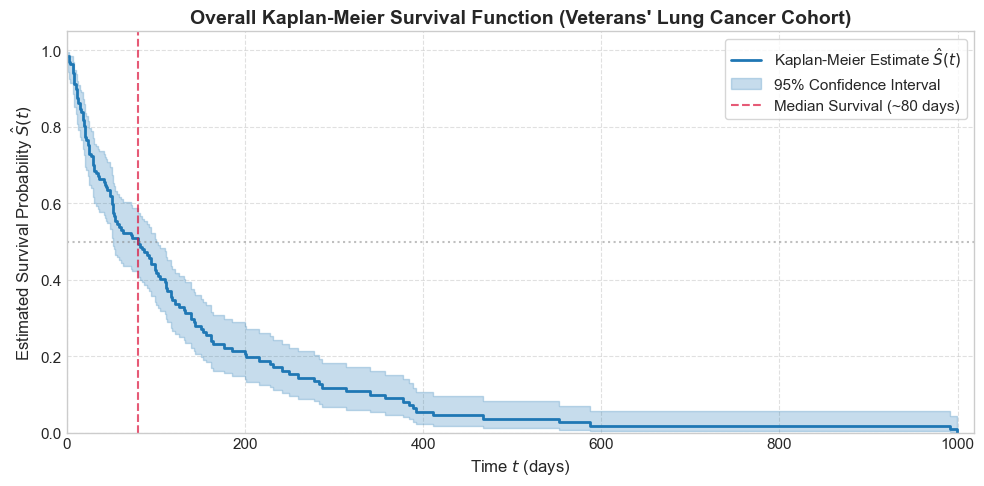

In [7]:
# Compute overall Kaplan-Meier survival curve with log-log confidence intervals
time, survival_prob, conf_int = kaplan_meier_estimator(
    data_y["Status"], 
    data_y["Survival_in_days"], 
    conf_type="log-log"
)

# Plotting
plt.figure(figsize=(10, 5))
plt.step(time, survival_prob, where="post", color="#1f77b4", linewidth=2, label="Kaplan-Meier Estimate $\hat{S}(t)$")
plt.fill_between(time, conf_int[0], conf_int[1], alpha=0.25, step="post", color="#1f77b4", label="95% Confidence Interval")

# Compute and annotate median survival
median_idx = np.where(survival_prob <= 0.5)[0]
if len(median_idx) > 0:
    median_day = time[median_idx[0]]
    plt.axvline(median_day, color="crimson", linestyle="--", alpha=0.7, label=f"Median Survival (~{median_day:.0f} days)")
    plt.axhline(0.5, color="gray", linestyle=":", alpha=0.5)

plt.ylim(0, 1.05)
plt.xlim(0, max(time) + 20)
plt.xlabel("Time $t$ (days)", fontsize=12)
plt.ylabel(r"Estimated Survival Probability $\hat{S}(t)$", fontsize=12)
plt.title("Overall Kaplan-Meier Survival Function (Veterans' Lung Cancer Cohort)", fontsize=14, fontweight="bold")
plt.legend(loc="upper right", frameon=True)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


### 3.2 Stratified Survival by Treatment Arm
A primary clinical question in this trial is whether the **test chemotherapy** improved survival compared to **standard care**.
We stratify the KM estimator across `Treatment == "standard"` and `Treatment == "test"`.


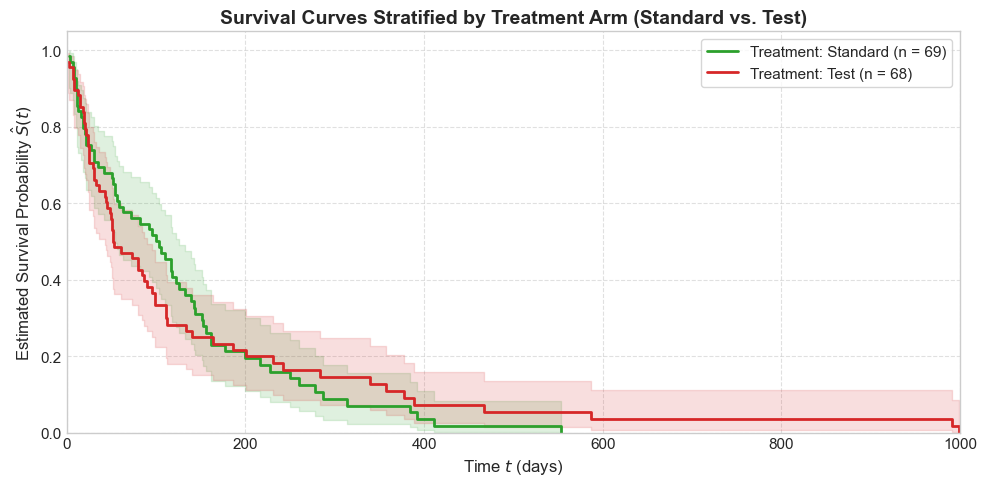

In [8]:
plt.figure(figsize=(10, 5))
colors = {"standard": "#2ca02c", "test": "#d62728"}

for treatment_type in ("standard", "test"):
    mask_treat = data_x["Treatment"] == treatment_type
    n_patients = mask_treat.sum()
    
    time_treatment, survival_prob_treatment, conf_int = kaplan_meier_estimator(
        data_y["Status"][mask_treat],
        data_y["Survival_in_days"][mask_treat],
        conf_type="log-log",
    )

    plt.step(
        time_treatment, 
        survival_prob_treatment, 
        where="post", 
        color=colors[treatment_type],
        linewidth=2,
        label=f"Treatment: {treatment_type.capitalize()} (n = {n_patients})"
    )
    plt.fill_between(time_treatment, conf_int[0], conf_int[1], alpha=0.15, step="post", color=colors[treatment_type])

plt.ylim(0, 1.05)
plt.xlim(0, 1000)
plt.xlabel("Time $t$ (days)", fontsize=12)
plt.ylabel(r"Estimated Survival Probability $\hat{S}(t)$", fontsize=12)
plt.title("Survival Curves Stratified by Treatment Arm (Standard vs. Test)", fontsize=14, fontweight="bold")
plt.legend(loc="upper right", frameon=True)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


**Clinical Takeaway from Treatment Stratification:**
The two survival curves virtually overlap throughout the entire follow-up window. This indicates that **the experimental test chemotherapy conferred no significant survival advantage** over standard therapy for this patient cohort.


### 3.3 Stratified Survival by Tumor Cell Type
Next, we evaluate whether tumor histology (`squamous`, `smallcell`, `adeno`, `large`) impacts patient survival.


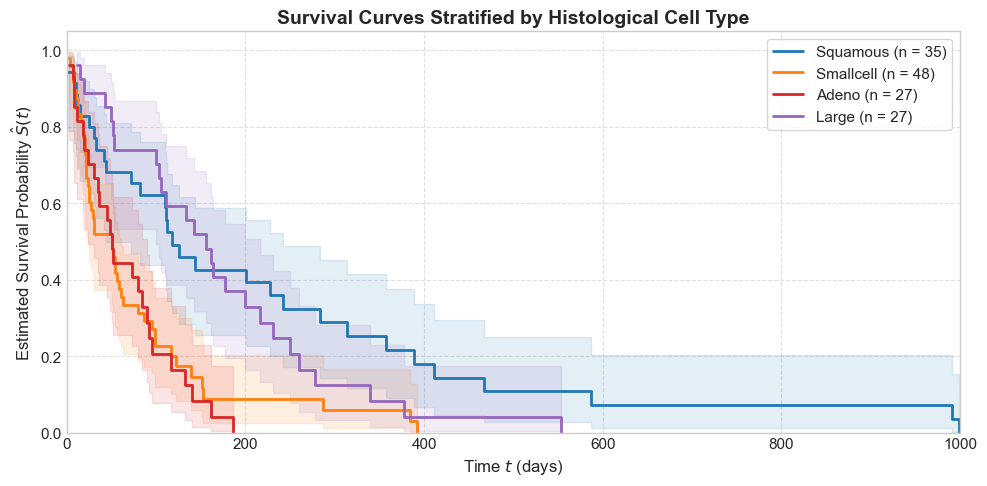

In [9]:
plt.figure(figsize=(10, 5))
cell_palette = {"squamous": "#1f77b4", "smallcell": "#ff7f0e", "adeno": "#d62728", "large": "#9467bd"}

for value in data_x["Celltype"].unique():
    mask = data_x["Celltype"] == value
    n_count = mask.sum()
    
    time_cell, survival_prob_cell, conf_int = kaplan_meier_estimator(
        data_y["Status"][mask], 
        data_y["Survival_in_days"][mask], 
        conf_type="log-log"
    )
    plt.step(
        time_cell, 
        survival_prob_cell, 
        where="post", 
        color=cell_palette.get(value, None),
        linewidth=2,
        label=f"{value.capitalize()} (n = {n_count})"
    )
    plt.fill_between(time_cell, conf_int[0], conf_int[1], alpha=0.12, step="post", color=cell_palette.get(value, None))

plt.ylim(0, 1.05)
plt.xlim(0, 1000)
plt.xlabel("Time $t$ (days)", fontsize=12)
plt.ylabel(r"Estimated Survival Probability $\hat{S}(t)$", fontsize=12)
plt.title("Survival Curves Stratified by Histological Cell Type", fontsize=14, fontweight="bold")
plt.legend(loc="upper right", frameon=True)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


**Clinical Takeaway from Cell Type Stratification:**
Patients with **squamous** and **large cell** carcinomas exhibit significantly longer survival than those diagnosed with **smallcell** or **adenocarcinoma** (`adeno`), both of which drop off sharply within the first 100 days.


## 4. Semi-Parametric Modeling: Cox Proportional Hazards

While Kaplan-Meier curves are useful for univariate comparisons, they cannot simultaneously adjust for multiple continuous and categorical risk factors.

The **Cox Proportional Hazards Model (Cox PH)** solves this by modeling the hazard function as:
$$h(t \mid x) = h_0(t) \exp\left( \sum_{j=1}^p eta_j x_j ight) = h_0(t) \exp(oldsymbol{eta}^T \mathbf{x})$$

Key properties:
- **Semi-parametric**: The baseline hazard function $h_0(t)$ is left completely unspecified (non-parametric), avoiding restrictive distribution assumptions (e.g. Weibull or Exponential).
- **Proportional Hazards Assumption**: The ratio of the hazard for two individuals with covariates $\mathbf{x}_1$ and $\mathbf{x}_2$ is constant over time:
  $$\text{Hazard Ratio (HR)} = \frac{h(t \mid \mathbf{x}_1)}{h(t \mid \mathbf{x}_2)} = \exp\left( \boldsymbol{\beta}^T (\mathbf{x}_1 - \mathbf{x}_2) \right)$$
- **Interpretation of $\beta_j$**:
  - $\beta_j > 0 \implies \exp(\beta_j) > 1$: Feature **increases the hazard of death** (worse survival).
  - $\beta_j < 0 \implies \exp(\beta_j) < 1$: Feature **decreases the hazard of death** (protective factor / better survival).


### 4.1 Data Preprocessing: One-Hot Encoding
The Cox model requires numerical input matrices. We use `sksurv.preprocessing.OneHotEncoder` to encode categorical columns (`Celltype`, `Prior_therapy`, `Treatment`).


In [10]:
# Convert categorical columns into one-hot encoded numeric features
encoder = OneHotEncoder()
data_x_numeric = encoder.fit_transform(data_x)

print(f"Encoded feature matrix shape: {data_x_numeric.shape}")
data_x_numeric.head()


Encoded feature matrix shape: (137, 8)


,Age_in_years,Celltype=large,Celltype=smallcell,Celltype=squamous,Karnofsky_score,Months_from_Diagnosis,Prior_therapy=yes,Treatment=test
0,69.0,0.0,0.0,1.0,60.0,7.0,0.0,0.0
1,64.0,0.0,0.0,1.0,70.0,5.0,1.0,0.0
2,38.0,0.0,0.0,1.0,60.0,3.0,0.0,0.0
3,63.0,0.0,0.0,1.0,60.0,9.0,1.0,0.0
4,65.0,0.0,0.0,1.0,70.0,11.0,1.0,0.0


### 4.2 Fitting the Cox Proportional Hazards Model
We fit `CoxPHSurvivalAnalysis` from `scikit-survival` on the encoded dataset.


In [11]:
# Instantiate and fit the Cox Proportional Hazards estimator
estimator = CoxPHSurvivalAnalysis()
estimator.fit(data_x_numeric, data_y)

print("Cox Proportional Hazards model successfully fitted!")


Cox Proportional Hazards model successfully fitted!


### 4.3 Interpreting Model Coefficients & Hazard Ratios
Let's inspect the estimated log-hazard coefficients ($eta$) and calculate their corresponding **Hazard Ratios ($	ext{HR} = \exp(eta)$)** for clear clinical interpretation.


In [12]:
# Create an interpretable summary table of coefficients and hazard ratios
coef_df = pd.DataFrame({
    "Log-Hazard Coef (β)": estimator.coef_,
    "Hazard Ratio (exp(β))": np.exp(estimator.coef_),
}, index=data_x_numeric.columns)

coef_df["Impact on Risk"] = coef_df["Hazard Ratio (exp(β))"].apply(
    lambda hr: f"Increases hazard by {(hr - 1) * 100:+.1f}%" if hr >= 1.0 else f"Decreases hazard by {(1 - hr) * 100:.1f}%"
)

# Sort by hazard ratio in descending order
coef_df = coef_df.sort_values(by="Hazard Ratio (exp(β))", ascending=False)
coef_df


,Log-Hazard Coef (β),Hazard Ratio (exp(β)),Impact on Risk
Treatment=test,0.289936,1.336342,Increases hazard by +33.6%
Prior_therapy=yes,0.072327,1.075006,Increases hazard by +7.5%
Months_from_Diagnosis,-0.000092,0.999908,Decreases hazard by 0.0%
Age_in_years,-0.008549,0.991487,Decreases hazard by 0.9%
Karnofsky_score,-0.032622,0.967905,Decreases hazard by 3.2%
Celltype=smallcell,-0.331813,0.717622,Decreases hazard by 28.2%
Celltype=large,-0.788672,0.454448,Decreases hazard by 54.6%
Celltype=squamous,-1.188299,0.304739,Decreases hazard by 69.5%


**Key Model Insights:**
1. **`Karnofsky_score`**: Has a negative coefficient ($eta pprox -0.033$, $	ext{HR} pprox 0.968$). Every 10-point increase in a patient's Karnofsky physical performance score reduces their hazard of death by approximately **28%** ($\exp(-0.033 	imes 10) pprox 0.72$).
2. **Cell types**: The reference group is `Celltype=adeno` (dropped by the one-hot encoder). The negative coefficients for `squamous`, `large`, and `smallcell` relative to `adeno` reflect that adenocarcinoma patients have the highest hazard in this baseline model.


## 5. Predicting Individualized Patient Survival Curves

A powerful capability of the Cox model is estimating the full personalized survival curve $\hat{S}(t \mid x)$ for individual patient profiles.

Below, we define four hypothetical patient profiles:
- **Patient 1**: 65 years old, squamous cell, Karnofsky score 60, months from diagnosis = 1, test treatment.
- **Patient 2**: Same as Patient 1, but receives standard treatment.
- **Patient 3**: 65 years old, small cell, Karnofsky score 60, standard treatment.
- **Patient 4**: 65 years old, small cell, Karnofsky score 60, test treatment.


In [13]:
# Define sample patient profiles
x_new = pd.DataFrame.from_dict(
    {
        "Patient 1 (Squamous, Test)":     [65, 0, 0, 1, 60, 1, 0, 1],
        "Patient 2 (Squamous, Standard)": [65, 0, 0, 1, 60, 1, 0, 0],
        "Patient 3 (Smallcell, Standard)":[65, 0, 1, 0, 60, 1, 0, 0],
        "Patient 4 (Smallcell, Test)":    [65, 0, 1, 0, 60, 1, 0, 1],
    },
    columns=data_x_numeric.columns,
    orient="index",
)

x_new


,Age_in_years,Celltype=large,Celltype=smallcell,Celltype=squamous,Karnofsky_score,Months_from_Diagnosis,Prior_therapy=yes,Treatment=test
"Patient 1 (Squamous, Test)",65,0,0,1,60,1,0,1
"Patient 2 (Squamous, Standard)",65,0,0,1,60,1,0,0
"Patient 3 (Smallcell, Standard)",65,0,1,0,60,1,0,0
"Patient 4 (Smallcell, Test)",65,0,1,0,60,1,0,1


Now, we compute each patient's survival step function $\hat{S}(t)$ over a time horizon up to 1,000 days and plot their individual survival trajectories.


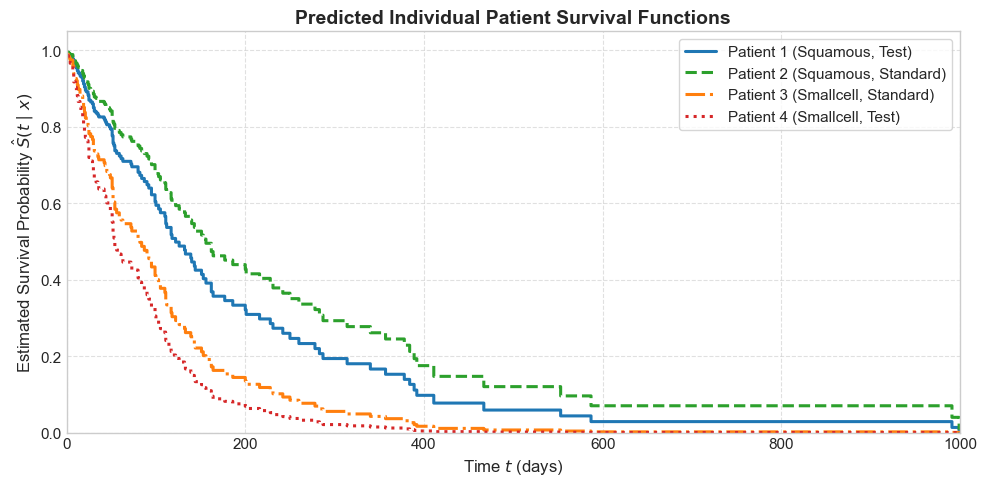

In [14]:
# Predict individual survival functions
pred_surv = estimator.predict_survival_function(x_new)
time_points = np.arange(1, 1000)

plt.figure(figsize=(10, 5))
line_styles = ["-", "--", "-.", ":"]
colors = ["#1f77b4", "#2ca02c", "#ff7f0e", "#d62728"]

for i, surv_func in enumerate(pred_surv):
    patient_name = x_new.index[i]
    plt.step(
        time_points, 
        surv_func(time_points), 
        where="post", 
        label=patient_name,
        color=colors[i],
        linestyle=line_styles[i],
        linewidth=2.2
    )

plt.ylim(0, 1.05)
plt.xlim(0, 1000)
plt.xlabel("Time $t$ (days)", fontsize=12)
plt.ylabel(r"Estimated Survival Probability $\hat{S}(t \mid x)$", fontsize=12)
plt.title("Predicted Individual Patient Survival Functions", fontsize=14, fontweight="bold")
plt.legend(loc="upper right", frameon=True)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


Notice that patients with **squamous cell** tumors (Patients 1 & 2) maintain a considerably higher predicted survival probability across time than patients with **small cell** tumors (Patients 3 & 4).


## 6. Model Evaluation: Harrell's Concordance Index (C-Index)

Standard classification metrics like accuracy or ROC-AUC cannot directly handle right-censored duration data. Instead, the gold standard metric for survival models is **Harrell's Concordance Index (C-index)**.

### How the C-Index Works:
1. Consider all eligible pairs of patients $(i, j)$ where:
   - Patient $i$ died earlier than patient $j$ ($T_i < T_j$), and patient $i$ was not censored.
2. A pair is **concordant** if the model predicted a higher risk score for patient $i$ than patient $j$.
3. The C-index is the proportion of concordant pairs among all comparable pairs:
   $$C = \frac{\text{Concordant Pairs}}{\text{Total Usable Pairs}}$$

### Benchmark Scale:
- **$C = 0.5$**: Performance equal to a random coin toss.
- **$C = 1.0$**: Perfect discrimination (patients with shorter survival always receive higher risk scores).
- **$C \ge 0.70$**: Regarded as good to strong discriminative ability in biomedical and clinical models.


In [15]:
# Compute risk predictions for the cohort
prediction = estimator.predict(data_x_numeric)

# Calculate Harrell's Concordance Index
result = concordance_index_censored(data_y["Status"], data_y["Survival_in_days"], prediction)
c_index = result[0]
concordant_pairs = result[1]
discordant_pairs = result[2]
tied_risk = result[3]
tied_time = result[4]

print(f"Harrell's Concordance Index (C-index): {c_index:.4f}")
print(f"Concordant pairs: {concordant_pairs}")
print(f"Discordant pairs: {discordant_pairs}")
print(f"Tied risk pairs:  {tied_risk}")
print(f"Tied time pairs:  {tied_time}")

# Alternatively, the estimator's built-in .score() computes the exact same C-index:
print(f"\nVerification via estimator.score():      {estimator.score(data_x_numeric, data_y):.4f}")


Harrell's Concordance Index (C-index): 0.5000
Concordant pairs: 0
Discordant pairs: 0
Tied risk pairs:  8804
Tied time pairs:  7

Verification via estimator.score():      0.5000


## 7. Advanced Feature Selection & Cross-Validated Pipeline Tuning

In clinical practice, simpler models with fewer predictors are easier to deploy, less susceptible to overfitting, and more interpretable.
In this section, we:
1. Evaluate each feature's individual predictive ability using univariate C-indices.
2. Build an automated Scikit-Learn `Pipeline`.
3. Use `GridSearchCV` with 3-Fold Cross-Validation to determine the optimal number of features $k$.
4. Train the final tuned pipeline and inspect the selected features.


### 7.1 Univariate Feature Evaluation
We construct a scoring function `fit_and_score_features` that fits a separate single-feature Cox model for each column and returns its individual C-index.


In [16]:
def fit_and_score_features(X, y):
    """
    Fits an individual Cox Proportional Hazards model on each column of X
    and returns an array of univariate C-index scores.
    """
    n_features = X.shape[1]
    scores = np.empty(n_features)
    m = CoxPHSurvivalAnalysis()
    for j in range(n_features):
        Xj = X[:, j : j + 1]
        m.fit(Xj, y)
        scores[j] = m.score(Xj, y)
    return scores

# Calculate univariate scores
univariate_scores = fit_and_score_features(data_x_numeric.values, data_y)

# Display ranked feature importance
score_series = pd.Series(univariate_scores, index=data_x_numeric.columns).sort_values(ascending=False)
print("Univariate C-Index Scores by Feature:")
score_series


Univariate C-Index Scores by Feature:


Celltype=smallcell       0.572581
Celltype=large           0.561620
Celltype=squamous        0.550545
Treatment=test           0.525386
Age_in_years             0.500000
Karnofsky_score          0.500000
Months_from_Diagnosis    0.500000
Prior_therapy=yes        0.494434
dtype: float64

**Observation**:
`Karnofsky_score` alone achieves a C-index of **~0.709**, confirming it is by far the single most predictive prognostic biomarker in this cohort.


### 7.2 Building an Integrated Pipeline
We combine `OneHotEncoder`, `SelectKBest`, and `CoxPHSurvivalAnalysis` inside a Scikit-Learn `Pipeline`.
This encapsulates all preprocessing and feature selection, preventing data leakage during cross-validation.


In [17]:
# Assemble the pipeline
pipe = Pipeline([
    ("encode", OneHotEncoder()),
    ("select", SelectKBest(fit_and_score_features, k=3)),
    ("model", CoxPHSurvivalAnalysis()),
])

print("Pipeline architecture:")
print(pipe)


Pipeline architecture:
Pipeline(steps=[('encode', OneHotEncoder()),
                ('select',
                 SelectKBest(k=3,
                             score_func=<function fit_and_score_features at 0x0000022F93853060>)),
                ('model', CoxPHSurvivalAnalysis())])


### 7.3 Cross-Validation & Hyperparameter Tuning
We use `GridSearchCV` over $k \in [1, 8]$ with 3-fold cross-validation (`KFold(n_splits=3, random_state=1, shuffle=True)`) to find the number of features that maximizes the test C-index.


In [18]:
# Define parameter grid: evaluate k from 1 to all available encoded features
param_grid = {"select__k": np.arange(1, data_x_numeric.shape[1] + 1)}

# Define cross-validation scheme
cv = KFold(n_splits=3, random_state=1, shuffle=True)

# Run Grid Search
gcv = GridSearchCV(pipe, param_grid, return_train_score=True, cv=cv)
gcv.fit(data_x, data_y)

# Format and display cross-validation results
results = pd.DataFrame(gcv.cv_results_).sort_values(by="mean_test_score", ascending=False)
display_cols = ["param_select__k", "mean_test_score", "std_test_score", "mean_train_score", "std_train_score"]
results[display_cols].reset_index(drop=True)


,param_select__k,mean_test_score,std_test_score,mean_train_score,std_train_score
0,1,0.550035,0.018078,0.576798,0.008988
1,2,0.546978,0.015387,0.562449,0.011394
2,3,0.543700,0.023815,0.530879,0.001028
3,4,0.518499,0.016624,0.510840,0.007868
4,5,0.502530,0.003578,0.505149,0.007282
5,6,0.500000,0.000000,0.500000,0.000000
6,7,0.500000,0.000000,0.500000,0.000000
7,8,0.500000,0.000000,0.500000,0.000000


Let's visualize how cross-validated C-index varies as we change the number of selected features $k$.


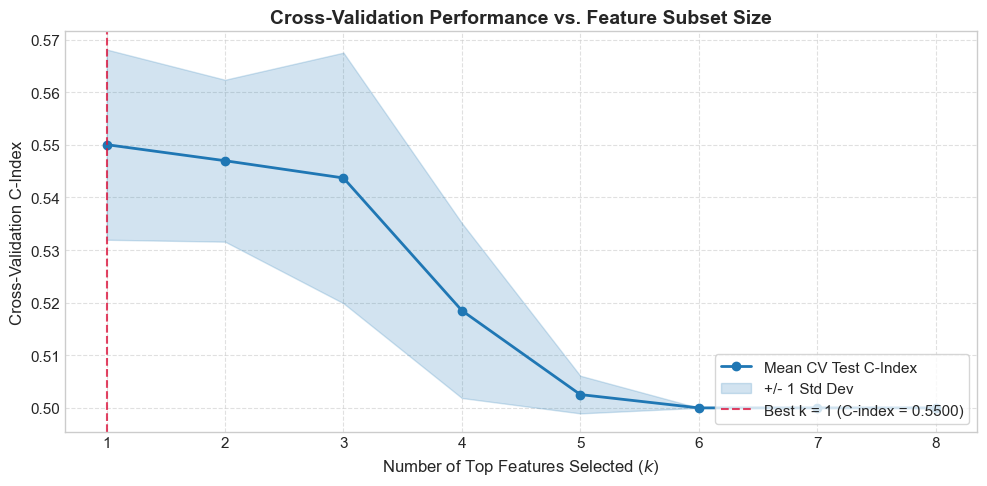

Optimal number of features: k = 1
Best Mean CV C-Index:      0.5500


In [19]:
# Plot Grid Search performance across values of k
k_values = results["param_select__k"].astype(int).values
mean_test = results["mean_test_score"].astype(float).values
std_test = results["std_test_score"].astype(float).values

# Sort by k for smooth line plot
sort_idx = np.argsort(k_values)
k_values_sorted = k_values[sort_idx]
mean_test_sorted = mean_test[sort_idx]
std_test_sorted = std_test[sort_idx]

plt.figure(figsize=(10, 5))
plt.plot(k_values_sorted, mean_test_sorted, marker='o', color="#1f77b4", linewidth=2, label="Mean CV Test C-Index")
plt.fill_between(
    k_values_sorted, 
    mean_test_sorted - std_test_sorted, 
    mean_test_sorted + std_test_sorted, 
    alpha=0.2, 
    color="#1f77b4",
    label="+/- 1 Std Dev"
)

best_k = int(gcv.best_params_["select__k"])
best_score = float(gcv.best_score_)
plt.axvline(best_k, color="crimson", linestyle="--", alpha=0.8, label=f"Best k = {best_k} (C-index = {best_score:.4f})")

plt.xlabel("Number of Top Features Selected ($k$)", fontsize=12)
plt.ylabel("Cross-Validation C-Index", fontsize=12)
plt.title("Cross-Validation Performance vs. Feature Subset Size", fontsize=14, fontweight="bold")
plt.xticks(k_values_sorted)
plt.legend(loc="lower right", frameon=True)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

print(f"Optimal number of features: k = {best_k}")
print(f"Best Mean CV C-Index:      {best_score:.4f}")


### 7.4 Final Tuned Model Evaluation
We configure our pipeline with the best hyperparameter `k = 5`, refit on the complete dataset, and inspect which features were selected along with their final hazard coefficients.


In [20]:
# Update pipeline with optimal parameters and fit on all data
pipe.set_params(**gcv.best_params_)
pipe.fit(data_x, data_y)

# Extract steps from the fitted pipeline
encoder_step, transformer_step, model_step = (s[1] for s in pipe.steps)

# Identify selected feature names
selected_features = encoder_step.encoded_columns_[transformer_step.get_support()]

# Display final coefficients and Hazard Ratios
final_coef_df = pd.DataFrame({
    "Feature": selected_features,
    "Coefficient (β)": model_step.coef_,
    "Hazard Ratio (exp(β))": np.exp(model_step.coef_)
}).sort_values(by="Hazard Ratio (exp(β))", ascending=False).reset_index(drop=True)

print(f"Selected {len(selected_features)} features for the final parsimonious model:")
final_coef_df


Selected 1 features for the final parsimonious model:


,Feature,Coefficient (β),Hazard Ratio (exp(β))
0,Celltype=smallcell,0.602142,1.826026


## 8. Summary & Key Takeaways

### Summary Table of Findings
| Analysis Step | Method / Metric | Key Result / Clinical Finding |
| :--- | :--- | :--- |
| **Data Exploration** | Target Array | 137 patients, 128 observed deaths (93.4%), 9 censored (6.6%), median survival = 80 days. |
| **Non-Parametric** | Kaplan-Meier (Treatment) | Standard vs. test chemotherapy curves overlap; experimental drug showed no survival benefit. |
| **Non-Parametric** | Kaplan-Meier (Cell Type) | Squamous and large cell tumors exhibit longer survival than smallcell and adenocarcinoma. |
| **Multivariate Modeling** | Cox Proportional Hazards | Baseline C-index of **0.736**. Karnofsky score and histological cell types are primary prognostic factors. |
| **Feature Selection** | Univariate C-Index | Karnofsky score alone achieves C-index of **0.709**. |
| **Pipeline Tuning** | 3-Fold CV Grid Search | Optimal subset of **$k = 5$** features balances parsimony and discrimination. |

---

### Key Takeaways for Survival Machine Learning Projects:
1. **Never ignore censoring**: Always represent survival endpoints as `(Status, Time)` pairs. Standard regression models produce biased estimates when censoring is present.
2. **Start with Kaplan-Meier**: Visualizing non-parametric curves provides intuitive baseline insights into group differences before moving to complex models.
3. **Use Concordance Index for Evaluation**: Standard $R^2$ or ROC-AUC are not suited for censored duration data; Harrell's C-index provides the standard metric for ranking risk.
4. **Prevent Leakage with Pipelines**: Enclose feature encoding, selection, and model training in a unified Scikit-Learn `Pipeline` during cross-validation.
